# Сравнительный анализ номинальных и реальных потребительских расходов населения России по данным СберИндекса за 2018–2026 годы

##Получение данных

В рамках данного этапа исследования были получены данные о номинальных и реальных потребительских расходах населения России с использованием API платформы СберИндекс.

Полученные данные были объединены в единую таблицу по временному признаку. В итоговый набор данных вошли показатели расходов по четырём категориям: непродовольственные товары, общественное питание, продовольственные товары и услуги, а также суммарные значения номинальных и реальных расходов.

На этапе предобработки была выполнена проверка качества данных. Были проанализированы типы данных, наличие пропусков и дубликатов. Проверка показала, что данные являются корректными и пригодными для дальнейшего анализа.

In [3]:
# импорты библиотек
import pandas as pd
import numpy as np
import requests
import base64
import json
import urllib3
import uuid
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from urllib.parse import quote

In [5]:
# Отключение предупреждений SSL
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# Настройки отображения таблиц
pd.set_option('display.max_columns', None)


# Адрес API СберИндекса
URL = 'https://www.sberindex.ru/api/sowa'


def decode_value(value):
    """Декодирует значения из формата API СберИндекса."""
    if isinstance(value, str):
        if value.startswith('__string__'):
            encoded_value = value.replace('__string__', '')
            return base64.b64decode(encoded_value).decode('utf-8')

        if value.startswith('__number__'):
            numeric_value = value.replace('__number__', '')
            return float(numeric_value)

    return value


def load_sber_dataset(dataset_name, type_code, referer):
    # Заголовки запроса
    headers = {
        'User-Agent': 'Mozilla/5.0',
        'Content-Type': 'application/json',
        'Origin': 'https://www.sberindex.ru',
        'Referer': referer,
        'rquid': uuid.uuid4().hex,
    }
    # Фильтр данных
    filter_data = {
        'REF_AREA': '643',
        'FREQ': 'M',
        'SOURCE': 'SI',
        'TYPE': str(type_code),
    }

    # Преобразование фильтра в строку JSON без пробелов
    filter_text = json.dumps(
        filter_data,
        ensure_ascii=False,
        separators=(',', ':'),
    )

    # Формирование маршрута запроса
    route = (
        f'/dataset/v1/{dataset_name}'
        f'?filter={quote(filter_text)}'
        '&limit=1000&offset=0'
    )

    # Кодирование маршрута в Base64
    route_encoded = base64.b64encode(
        route.encode('utf-8'),
    ).decode('utf-8')

    # Тело POST-запроса
    payload = {
        'SOWA': {
            'method': 'GET',
            'route': route_encoded,
            'data': {
                'type': 'object',
                'value': [],
            },
        },
    }

    # Отправка запроса
    response = requests.post(
        URL,
        headers=headers,
        json=payload,
        verify=False,
    )

    print(dataset_name, type_code, response.status_code)

    # Проверка статуса ответа
    if response.status_code != 200:
        print(response.text[:500])
        return pd.DataFrame()

    # Получение JSON-ответа
    data_json = response.json()
    items = data_json['SOWA']['data']['value']

    fields_raw = None
    rows_raw = None

    # Поиск названий столбцов и строк данных
    for item in items:
        if item.get('key') == 'fields':
            fields_raw = item.get('value')

        if item.get('key') == 'data':
            rows_raw = item.get('value')

    # Проверка наличия данных
    if fields_raw is None or rows_raw is None:
        return pd.DataFrame()

    # Декодирование названий столбцов
    columns = []

    for column in fields_raw:
        columns.append(decode_value(column))

    # Декодирование строк данных
    rows = []

    for row in rows_raw:
        new_row = []

        for value in row:
            new_row.append(decode_value(value))

        rows.append(new_row)

    # Создание DataFrame
    dataset = pd.DataFrame(rows, columns=columns)

    # Проверка нужных столбцов
    if 'period' not in dataset.columns or 'value' not in dataset.columns:
        return pd.DataFrame()

    dataset = dataset[['period', 'value']]

    return dataset


# Загрузка номинальных расходов
nominal_types = {
    '101': 'nominal_non_food_products',
    '102': 'nominal_public_catering',
    '103': 'nominal_food_products',
    '104': 'nominal_services',
}

nominal_df = None

for type_code, column_name in nominal_types.items():
    temp_df = load_sber_dataset(
        dataset_name='consumer-spending',
        type_code=type_code,
        referer='https://www.sberindex.ru/ru/dashboards/consumer-spending',
    )

    if temp_df.empty:
        print('Не загрузился nominal TYPE:', type_code)
        continue

    # Переименование столбца value
    temp_df = temp_df.rename(
        columns={
            'value': column_name,
        },
    )

    # Объединение категорий
    if nominal_df is None:
        nominal_df = temp_df
    else:
        nominal_df = nominal_df.merge(
            temp_df,
            on='period',
            how='outer',
        )


# Расчёт общего объёма номинальных расходов
nominal_df['nominal_total'] = nominal_df[
    [
        'nominal_non_food_products',
        'nominal_public_catering',
        'nominal_food_products',
        'nominal_services',
    ]
].sum(axis=1)


# Загрузка реальных расходов
real_types = {
    '101': 'real_non_food_products',
    '102': 'real_public_catering',
    '103': 'real_food_products',
    '104': 'real_services',
    '105': 'real_total',
}

real_df = None

for type_code, column_name in real_types.items():
    temp_df = load_sber_dataset(
        dataset_name='consumper-spending-index-sa',
        type_code=type_code,
        referer=(
            'https://www.sberindex.ru/ru/dashboards/'
            'consumper-spending-index-sa'
        ),
    )

    if temp_df.empty:
        print('Не загрузился real TYPE:', type_code)
        continue

    # Переименование столбца value
    temp_df = temp_df.rename(
        columns={
            'value': column_name,
        },
    )

    # Объединение категорий
    if real_df is None:
        real_df = temp_df
    else:
        real_df = real_df.merge(
            temp_df,
            on='period',
            how='outer',
        )


# Добавление пустых столбцов, если часть реальных данных не загрузилась
for column_name in [
    'real_non_food_products',
    'real_public_catering',
    'real_food_products',
    'real_services',
    'real_total',
]:
    if column_name not in real_df.columns:
        real_df[column_name] = np.nan


# Преобразование даты
nominal_df['period'] = pd.to_datetime(nominal_df['period'])
real_df['period'] = pd.to_datetime(real_df['period'])


# Объединение номинальных и реальных данных
df = nominal_df.merge(
    real_df,
    on='period',
    how='inner',
)

df = df.sort_values('period').reset_index(drop=True)


# Формирование итоговой таблицы
df = df[
    [
        'period',
        'nominal_non_food_products',
        'nominal_public_catering',
        'nominal_food_products',
        'nominal_services',
        'nominal_total',
        'real_non_food_products',
        'real_public_catering',
        'real_food_products',
        'real_services',
        'real_total',
    ]
]


# Переименование столбца даты
df = df.rename(
    columns={
        'period': 'date',
    },
)


# Проверка результата
print(df.shape)

display(df.head())

consumer-spending 101 200
consumer-spending 102 200
consumer-spending 103 200
consumer-spending 104 200
consumper-spending-index-sa 101 200
consumper-spending-index-sa 102 200
consumper-spending-index-sa 103 200
consumper-spending-index-sa 104 200
consumper-spending-index-sa 105 200
(90, 11)


,date,nominal_non_food_products,nominal_public_catering,nominal_food_products,nominal_services,nominal_total,real_non_food_products,real_public_catering,real_food_products,real_services,real_total
0,2018-11-30 21:00:00+00:00,1719.39,169.78,1592.16,891.21,4372.54,100.00,100.00,100.00,100.00,100.00
1,2018-12-31 21:00:00+00:00,1291.65,134.81,1215.82,828.09,3470.37,99.13,99.22,100.00,99.77,99.58
2,2019-01-31 21:00:00+00:00,1259.41,130.14,1195.18,827.21,3411.94,99.01,99.14,99.85,100.65,99.69
3,2019-02-28 21:00:00+00:00,1379.37,138.54,1311.02,860.49,3689.42,98.69,100.44,100.51,101.63,100.09
4,2019-03-31 21:00:00+00:00,1368.53,141.66,1288.40,865.86,3664.45,98.74,100.26,100.27,101.41,99.96


In [6]:
# Проверка качества данных
print('Размер итоговой таблицы:')
print(df.shape)

# Проверка типов данных
print('\nТипы данных:')

display(
    df.dtypes
)

# Проверка пропусков
print('\nКоличество пропусков по столбцам:')

missing_values = df.isna().sum()

display(missing_values)

# Проверка дубликатов
duplicates = df.duplicated().sum()

print(
    '\nКоличество дубликатов:',
    duplicates
)

Размер итоговой таблицы:
(90, 11)

Типы данных:


,0
date,"datetime64[ns, UTC]"
nominal_non_food_products,float64
nominal_public_catering,float64
nominal_food_products,float64
nominal_services,float64
nominal_total,float64
real_non_food_products,float64
real_public_catering,float64
real_food_products,float64
real_services,float64



Количество пропусков по столбцам:


,0
date,0
nominal_non_food_products,0
nominal_public_catering,0
nominal_food_products,0
nominal_services,0
nominal_total,0
real_non_food_products,0
real_public_catering,0
real_food_products,0
real_services,0



Количество дубликатов: 0


---

Дополнительно были сформированы новые признаки, необходимые для проведения исследования: год наблюдения, номер месяца, номер квартала, темпы роста номинальных расходов, темпы роста реальных расходов и показатель gap, отражающий разницу между темпами роста номинальных и реальных расходов.

В результате был сформирован подготовленный набор данных, содержащий 90 ежемесячных наблюдений и полный набор показателей, необходимых для проведения статистического анализа, проверки гипотез и построения визуализаций.

In [7]:
# Добавление новых столбцов

# Перевод даты к московскому времени
df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None) + pd.Timedelta(hours=3)

# Год, месяц, квартал
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Темп роста номинальных расходов
df['nominal_growth_pct'] = (
    df['nominal_total'].pct_change() * 100
)

# Темп роста реального индекса
df['real_growth_pct'] = (
    df['real_total'].pct_change() * 100
)

# Разрыв между номинальным и реальным ростом
df['gap'] = (
    df['nominal_growth_pct']
    - df['real_growth_pct']
)

display(df.head())

,date,nominal_non_food_products,nominal_public_catering,nominal_food_products,nominal_services,nominal_total,real_non_food_products,real_public_catering,real_food_products,real_services,real_total,year,month,quarter,nominal_growth_pct,real_growth_pct,gap
0,2018-12-01,1719.39,169.78,1592.16,891.21,4372.54,100.00,100.00,100.00,100.00,100.00,2018,12,4,NaN,NaN,NaN
1,2019-01-01,1291.65,134.81,1215.82,828.09,3470.37,99.13,99.22,100.00,99.77,99.58,2019,1,1,-20.632630,-0.420000,-20.212630
2,2019-02-01,1259.41,130.14,1195.18,827.21,3411.94,99.01,99.14,99.85,100.65,99.69,2019,2,1,-1.683682,0.110464,-1.794146
3,2019-03-01,1379.37,138.54,1311.02,860.49,3689.42,98.69,100.44,100.51,101.63,100.09,2019,3,1,8.132617,0.401244,7.731373
4,2019-04-01,1368.53,141.66,1288.40,865.86,3664.45,98.74,100.26,100.27,101.41,99.96,2019,4,2,-0.676800,-0.129883,-0.546917


In [8]:
# Создание файла с датасетом
df.to_csv('sberindex_project.csv', index=False)

print('Файл sberindex_project.csv сохранён')

Файл sberindex_project.csv сохранён




---



##Что хотели узнать и что проверяли

1. Корреляция: как связаны между собой уровень расходов и индекс?
2. Структура: как изменились потребительские расходы с 2018 года?
3. Волатильность: какие категории трат стабильны, а какие изменяются от месяца к месяцу?
4. Кризисная чувствительность: какую статью расходов потребители урезают в первую очередь?
5. Кластеризация: можно ли разбить все месяцы на группы (стабильные, праздничные, кризисные)?
Аналитика для полученные данных:


###Гипотезы, предложенные до анализа:

1. Сезонность трат в кафе и на продукты имеет схожее поведение.
2. Номинальные расходы восстанавливаются быстрее реальных. потому что инфляция создает иллюзию роста, а покупательская способность возвращается медленне.
3. Резкий разрыв между номинальным и реальным ростом расходов может "предсказывать" будущие кризисы. Сначала расходится динамика, потом падает реальный индекс.

#Анализ и результаты

####**0. Кризисные месяцы**

  Для выявления кризисных периодов используется следующий алгоритм: сначала рассчитываются месячные темпы роста номинальных потребительских расходов, затем вычисляются среднее значение и стандартное отклонение ряда.
  
  Кризисными считаются месяцы, в которых темп роста оказался ниже границы:


> Кризисная граница = среднее значение - 2 * стандартное отклонение


Средний темп роста: 1.07
Стандартное отклонение: 8.54
Кризисная граница: -16.02
Количество кризисных месяцев: 6


,date,nominal_total,real_total,nominal_growth
1,2019-01-01,3470.37,99.58,-20.632630
13,2020-01-01,3670.85,102.70,-20.348865
16,2020-04-01,2774.98,73.08,-29.525212
25,2021-01-01,3813.76,101.35,-17.917284
37,2022-01-01,4452.33,108.56,-17.875509
85,2026-01-01,7111.15,123.86,-17.280564



Расшифровка индексов:
  Индекс 1 = January 2019
  Индекс 13 = January 2020
  Индекс 16 = April 2020
  Индекс 25 = January 2021
  Индекс 37 = January 2022
  Индекс 85 = January 2026


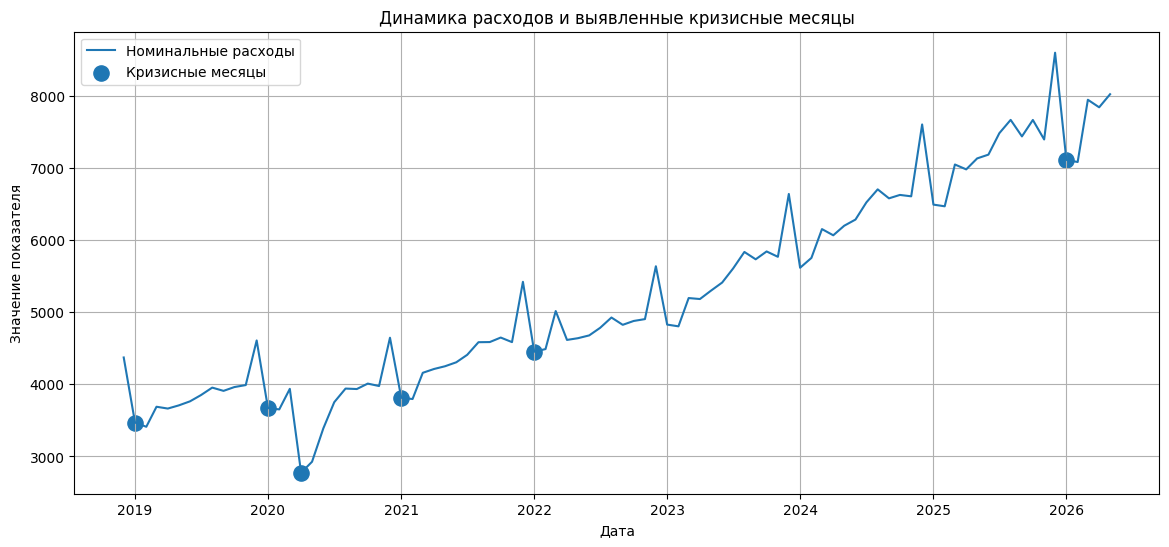

In [9]:
# Темпы роста номинальных расходов
df['nominal_growth'] = (
    df['nominal_total'].pct_change() * 100
)

# Средний темп роста
mean_growth = df['nominal_growth'].mean()

# Стандартное отклонение
std_growth = df['nominal_growth'].std()

# Кризисная граница
threshold = mean_growth - 2 * std_growth

print('Средний темп роста:', round(mean_growth, 2))
print('Стандартное отклонение:', round(std_growth, 2))
print('Кризисная граница:', round(threshold, 2))

# Все кризисные месяцы
crisis_df = df[
    df['nominal_growth'] < threshold
]

print('Количество кризисных месяцев:', len(crisis_df))

display(
    crisis_df[
        [
            'date',
            'nominal_total',
            'real_total',
            'nominal_growth'
        ]
    ]
)

print("\nРасшифровка индексов:")
for idx in crisis_df.index:
    month_name = crisis_df.loc[idx, 'date'].strftime('%B %Y')
    print(f"  Индекс {idx} = {month_name}")

crisis_periods = crisis_df['date'].dt.strftime('%Y-%m').tolist()

# Создание графика
plt.figure(figsize=(14,6))

plt.plot(
    df['date'],
    df['nominal_total'],
    label='Номинальные расходы'
)

plt.scatter(
    crisis_df['date'],
    crisis_df['nominal_total'],
    s=120,
    label='Кризисные месяцы'
)

plt.title(
    'Динамика расходов и выявленные кризисные месяцы'
)

plt.xlabel('Дата')
plt.ylabel('Значение показателя')

plt.legend()
plt.grid()

plt.show()

В результате были выявлены месяцы, характеризующиеся аномально низкими темпами роста потребительских расходов.
Данные периоды можно интерпретировать как кризисные точки временного ряда, поскольку снижение расходов существенно отличается от обычных колебаний показателя.

####**1. Корреляция расходов**

Насколько сильно связаны рост номинальных трат и реальный идекс?

Целью анализа является определение силы и направления связи между номинальными потребительскими расходами и индексом реальных расходов. Для оценки связи используется коэффициент корреляции Пирсона.

Значения коэффициента находятся в диапазоне от -1 до +1:

- близко к +1 — сильная прямая связь;
- близко к -1 — сильная обратная связь;
- около 0 — связь отсутствует.

Дополнительно строится диаграмма рассеяния.

Корреляционная матрица:
               nominal_total  real_total
nominal_total       1.000000    0.916373
real_total          0.916373    1.000000

Коэффициент корреляции: 0.9164


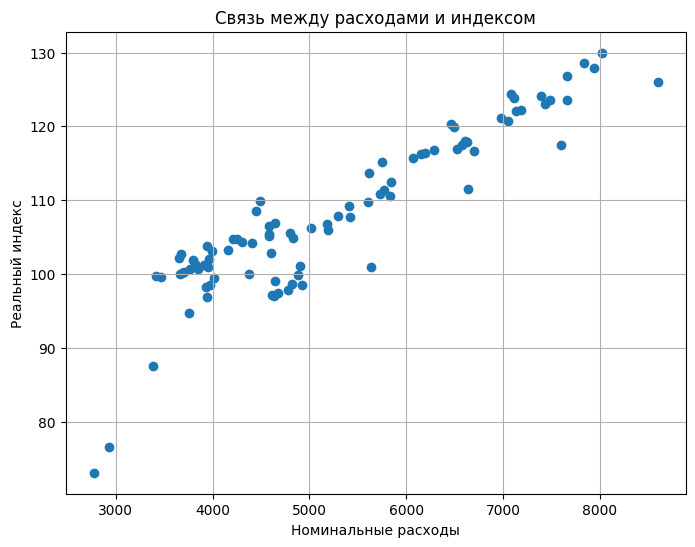


Вывод о корреляции данных:
Коэффициент корреляции между номинальными потребительскими расходами и индексом реальных расходов составил 0.9164. Полученное значение свидетельствует о том, что между показателями существует очень сильная прямая связь.


In [ ]:
# Расчёт корреляционной матрицы
corr_matrix = df[
    [
        'nominal_total',
        'real_total'
    ]
].corr()

print('Корреляционная матрица:')
print(corr_matrix)

# Расчёт коэффициента корреляции
corr_value = corr_matrix.loc[
    'nominal_total',
    'real_total'
]

print(
    '\nКоэффициент корреляции:',
    round(corr_value, 4)
)

# Построение диаграммы рассеяния
plt.figure(figsize=(8, 6))

plt.scatter(
    df['nominal_total'],
    df['real_total']
)

plt.title(
    'Связь между расходами и индексом'
)

plt.xlabel(
    'Номинальные расходы'
)

plt.ylabel(
    'Реальный индекс'
)

plt.grid()

plt.show()

# Интерпретация коэффициента корреляции
abs_corr = abs(corr_value)

if abs_corr < 0.3:
    strength = 'слабая'

elif abs_corr < 0.5:
    strength = 'умеренная'

elif abs_corr < 0.7:
    strength = 'заметная'

elif abs_corr < 0.9:
    strength = 'сильная'

else:
    strength = 'очень сильная'

# Определение направления связи
if corr_value > 0:
    direction = 'прямая'

elif corr_value < 0:
    direction = 'обратная'

else:
    direction = 'отсутствует'

# Вывод результатов
print('\nВывод о корреляции данных:')

print(
    f'Коэффициент корреляции между номинальными потребительскими расходами и индексом реальных расходов составил {corr_value:.4f}. Полученное значение свидетельствует о том, что между показателями существует {strength} {direction} связь.'
)

На основании полученного коэффициента корреляции была оценена сила взаимосвязи между показателями. Коэффициент положительный, поэтому рост номинальных расходов сопровождается ростом реальных расходов.


####**2. Как изменилась структура потребительских расходов с 2019 по 2025 год?**

Для анализа структурных изменений сравниваются средние значения категорий расходов в 2019 и 2025 годах. Берём эти года, так как они были полценные отчётные. 2018 и 2026 неполные.

Рассматриваются следующие категории:

- непродовольственные товары;
- общественное питание;
- продовольственные товары;
- услуги.

Для визуального сравнения используются круговые диаграммы.


Сравнение структуры номинальных расходов:


,2019,2025
nominal_non_food_products,1458.628333,2722.978333
nominal_public_catering,152.089167,439.183333
nominal_food_products,1343.398333,2470.355000
nominal_services,877.970000,1662.645000


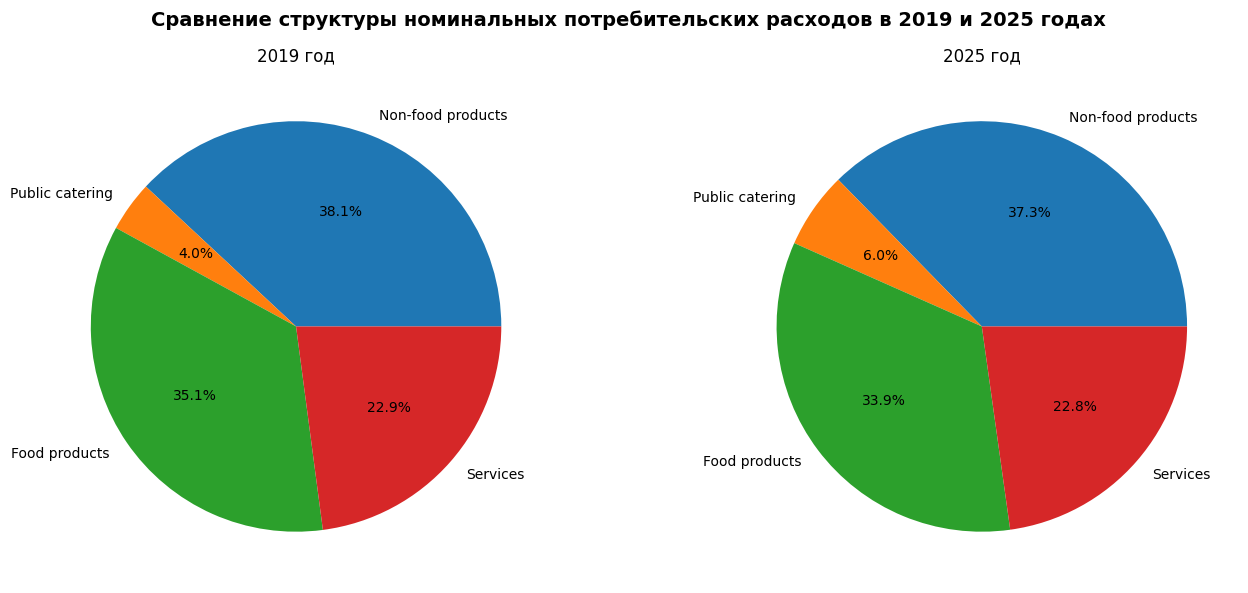

Изменение номинальных расходов (%):


,0
nominal_non_food_products,86.68
nominal_public_catering,188.77
nominal_food_products,83.89
nominal_services,89.37



Сравнение структуры реальных индексов:


,2019,2025
real_non_food_products,100.105833,126.427500
real_public_catering,101.968333,184.181667
real_food_products,101.005833,114.093333
real_services,101.913333,121.188333


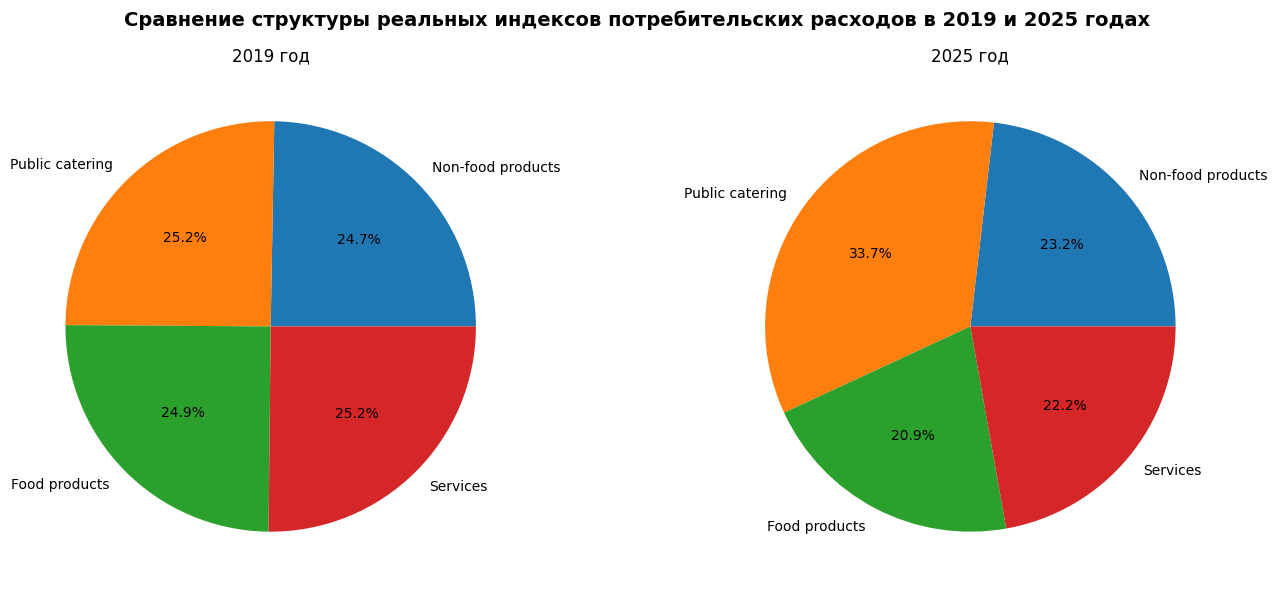

Изменение реальных индексов (%):


,0
real_non_food_products,26.29
real_public_catering,80.63
real_food_products,12.96
real_services,18.91


In [ ]:
# Список категорий номинальных расходов
nominal_cols = [
    'nominal_non_food_products',
    'nominal_public_catering',
    'nominal_food_products',
    'nominal_services'
]

# Список категорий реальных расходов
real_cols = [
    'real_non_food_products',
    'real_public_catering',
    'real_food_products',
    'real_services'
]

# Названия категорий для графиков
labels = [
    'Non-food products',
    'Public catering',
    'Food products',
    'Services'
]


# Анализ номинальных расходов

# Расчёт средних значений категорий за 2019 год
nominal_2019 = df[
    df['date'].dt.year == 2019
][nominal_cols].mean()

# Расчёт средних значений категорий за 2025 год
nominal_2025 = df[
    df['date'].dt.year == 2025
][nominal_cols].mean()

# Формирование таблицы сравнения
comparison_nominal = pd.DataFrame({
    '2019': nominal_2019,
    '2025': nominal_2025
})

print('\nСравнение структуры номинальных расходов:')
display(comparison_nominal)

# Построение круговых диаграмм
plt.figure(figsize=(14, 6))

plt.suptitle(
    'Сравнение структуры номинальных потребительских расходов в 2019 и 2025 годах',
    fontsize=14,
    fontweight='bold'
)

# Диаграмма за 2019 год
plt.subplot(1, 2, 1)

plt.pie(
    nominal_2019,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('2019 год')

# Диаграмма за 2025 год
plt.subplot(1, 2, 2)

plt.pie(
    nominal_2025,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('2025 год')

plt.tight_layout()
plt.show()

# Расчёт изменения категорий расходов
nominal_change = (
    (comparison_nominal['2025'] - comparison_nominal['2019'])
    / comparison_nominal['2019']
    * 100
)

print('Изменение номинальных расходов (%):')
display(nominal_change.round(2))


# Анализ реальных индексов

# Расчёт средних значений категорий за 2019 год
real_2019 = df[
    df['date'].dt.year == 2019
][real_cols].mean()

# Расчёт средних значений категорий за 2025 год
real_2025 = df[
    df['date'].dt.year == 2025
][real_cols].mean()

# Формирование таблицы сравнения
comparison_real = pd.DataFrame({
    '2019': real_2019,
    '2025': real_2025
})

print('\nСравнение структуры реальных индексов:')
display(comparison_real)

# Построение круговых диаграмм
plt.figure(figsize=(14, 6))

plt.suptitle(
    'Сравнение структуры реальных индексов потребительских расходов в 2019 и 2025 годах',
    fontsize=14,
    fontweight='bold'
)

# Диаграмма за 2019 год
plt.subplot(1, 2, 1)

plt.pie(
    real_2019,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('2019 год')

# Диаграмма за 2025 год
plt.subplot(1, 2, 2)

plt.pie(
    real_2025,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('2025 год')

plt.tight_layout()
plt.show()

# Расчёт изменения реальных индексов
real_change = (
    (comparison_real['2025'] - comparison_real['2019'])
    / comparison_real['2019']
    * 100
)

print('Изменение реальных индексов (%):')
display(real_change.round(2))


Сравнение структуры расходов позволяет определить категории, доля которых увеличилась или сократилась за рассматриваемый период. Наибольший рост свидетельствует об изменении потребительских предпочтений населения.

**Люди стали заметно больше тратить на кафе и услуги.**

####**3. Какая категория расходов наиболее/наименее волатильна?**

Волатильность характеризует степень изменчивости показателя во времени. Для оценки волатильности рассчитывается стандартное отклонение месячных темпов роста. Чем выше значение стандартного отклонения, тем сильнее колеблется соответствующая категория расходов.

Волатильность номинальных расходов:


,0
nominal_non_food_products,10.652868
nominal_food_products,9.902093
nominal_public_catering,9.558314
nominal_services,5.384039


Волатильность реальных индексов:


,0
real_public_catering,7.831997
real_non_food_products,5.925642
real_services,4.397796
real_food_products,2.013587


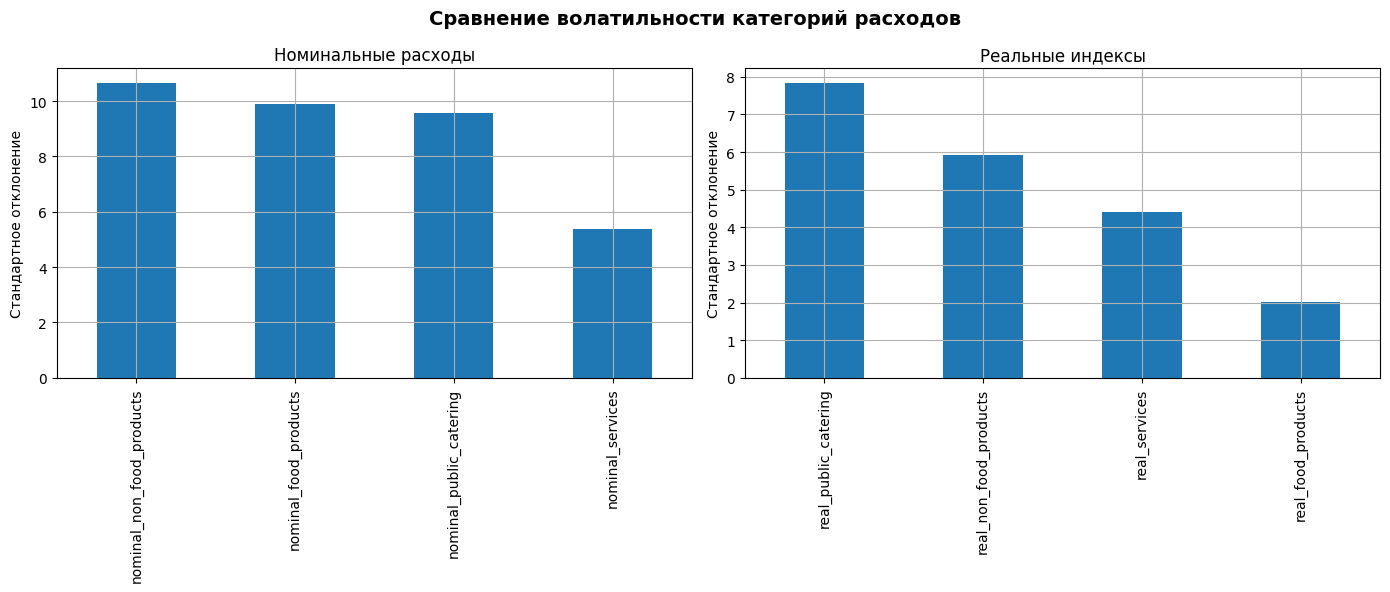


ВЫВОД ПО НОМИНАЛЬНЫМ РАСХОДАМ:
Наиболее волатильная категория: nominal_non_food_products
Наименее волатильная категория: nominal_services

ВЫВОД ПО РЕАЛЬНЫМ ИНДЕКСАМ:
Наиболее волатильная категория: real_public_catering
Наименее волатильная категория: real_food_products


In [ ]:
# Расчёт темпов роста номинальных расходов
nominal_growth = df[
    [
        'nominal_non_food_products',
        'nominal_public_catering',
        'nominal_food_products',
        'nominal_services'
    ]
].pct_change() * 100

# Расчёт волатильности номинальных расходов
nominal_volatility = nominal_growth.std()

print('Волатильность номинальных расходов:')
display(
    nominal_volatility.sort_values(
        ascending=False
    )
)

# Расчёт темпов роста реальных индексов
real_growth = df[
    [
        'real_non_food_products',
        'real_public_catering',
        'real_food_products',
        'real_services'
    ]
].pct_change() * 100

# Расчёт волатильности реальных индексов
real_volatility = real_growth.std()

print('Волатильность реальных индексов:')
display(
    real_volatility.sort_values(
        ascending=False
    )
)

# Построение графиков волатильности
plt.figure(figsize=(14, 6))

plt.suptitle(
    'Сравнение волатильности категорий расходов',
    fontsize=14,
    fontweight='bold'
)

# График волатильности номинальных расходов
plt.subplot(1, 2, 1)

nominal_volatility.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title('Номинальные расходы')
plt.ylabel('Стандартное отклонение')
plt.grid()

# График волатильности реальных индексов
plt.subplot(1, 2, 2)

real_volatility.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title('Реальные индексы')
plt.ylabel('Стандартное отклонение')
plt.grid()

plt.tight_layout()

plt.show()

# Формирование вывода по номинальным расходам
print('\nВЫВОД ПО НОМИНАЛЬНЫМ РАСХОДАМ:')

print(
    'Наиболее волатильная категория:',
    nominal_volatility.idxmax()
)

print(
    'Наименее волатильная категория:',
    nominal_volatility.idxmin()
)

# Формирование вывода по реальным индексам
print('\nВЫВОД ПО РЕАЛЬНЫМ ИНДЕКСАМ:')

print(
    'Наиболее волатильная категория:',
    real_volatility.idxmax()
)

print(
    'Наименее волатильная категория:',
    real_volatility.idxmin()
)

Наиболее волатильная категория сильнее реагирует на изменения экономической ситуации и потребительского спроса. Наименее волатильная категория характеризуется более стабильным поведением во времени.

В номинальных расходах мы считали волатильность **денежных трат**, а в реальных индексах - волатильность **покупателькой способности**. Так как это разные величины, то результаты двух измерений тоже получились разные.

В номинальном выражении сильнее всего изменяются непродовольственные товары (10.65) и продукты (9.90). В реальном выражении самым волатильным оказывается общепит (7.83), а продукты самым стабильным (2.01).

Наша интерпретация:
* продукты люди могут покупать впрок, делая запасы. Номинальные траты скачут, но реальное потребление остается стабильным.
* общепит не позволяет делать запасы. Люди резко меняют поведение в кризис и праздники, поэтому реальное потребление скачет сильно.
* непродовольственные товары волатильны везде, их покупку легко отложить или ускорить.
* услуги стабильны везде, так как это обязательные платежи.


####**4. Какие категории "просели" сильнее всего в кризисные месяцы?**

На предыдущем этапе кризисные месяцы были определены на основе данных: как месяцы, в которых темп роста номинальных потребительских расходов оказался ниже статистической кризисной границы. Здесь проанализируем темпы роста по каждой категории к выявленые кризисные месяцы.



Темпы роста номинальных расходов в кризисные месяцы:


,nominal_non_food_products_growth,nominal_public_catering_growth,nominal_food_products_growth,nominal_services_growth
date,,,,
January 2019,-24.877427,-20.597243,-23.637072,-7.082506
January 2020,-24.034444,-22.889275,-23.779238,-6.856368
April 2020,-39.900028,-50.259418,-14.067840,-33.709568
January 2021,-20.382681,-7.692830,-21.827289,-6.887329
January 2022,-21.113748,-9.662349,-22.517040,-3.913928
January 2026,-22.261419,-5.628326,-21.140403,-5.169450


Темпы роста реальных индексов в кризисные месяцы:


,real_non_food_products_growth,real_public_catering_growth,real_food_products_growth,real_services_growth
date,,,,
January 2019,-0.870000,-0.780000,0.000000,-0.230000
January 2020,-0.029231,-5.981466,0.038926,0.272692
April 2020,-39.627458,-51.380861,-14.224459,-34.012346
January 2021,3.086722,9.144335,1.670456,0.605417
January 2022,0.605683,3.686146,-0.076453,2.184763
January 2026,-4.988989,1.699656,0.155306,0.194112


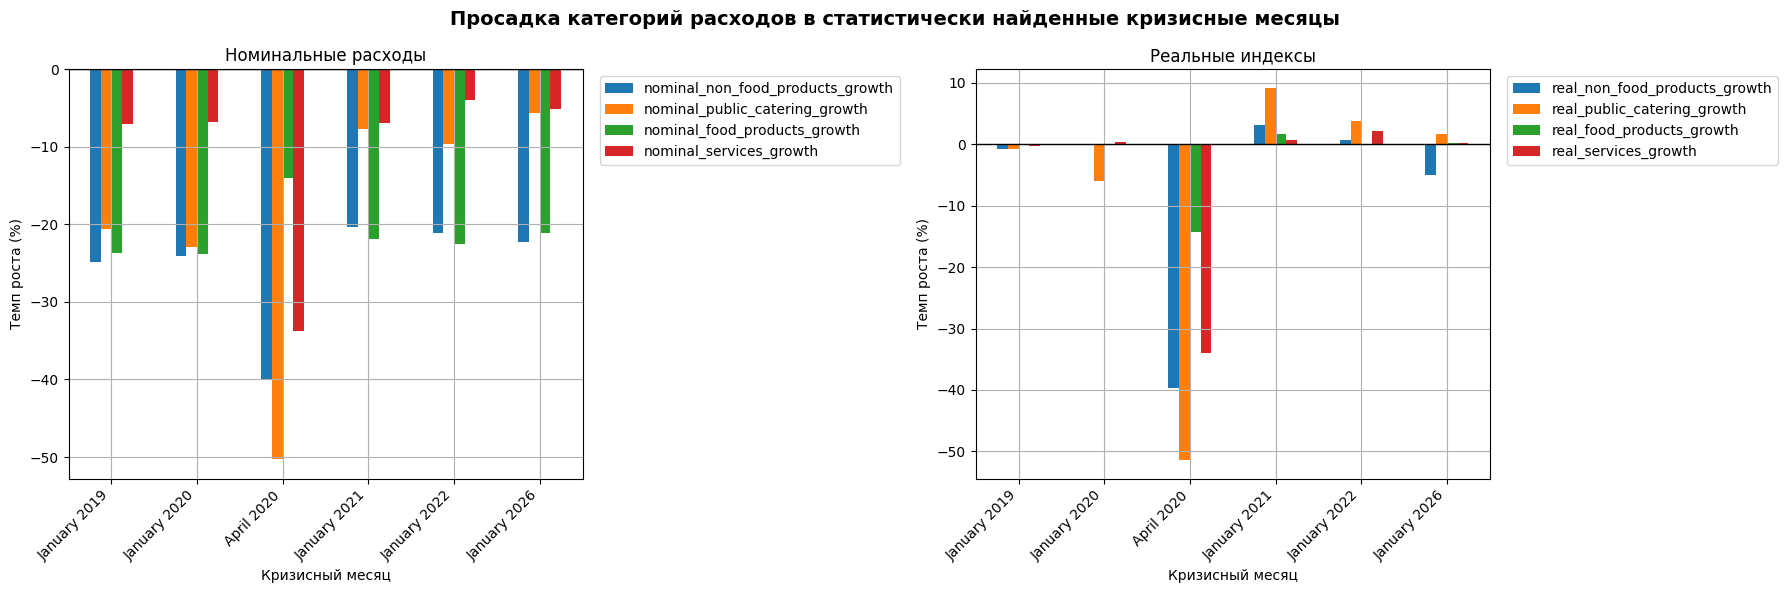


ВЫВОД ПО НОМИНАЛЬНЫМ РАСХОДАМ:
Наибольшая просадка наблюдалась в категории: nominal_public_catering_growth
Минимальное значение: -50.26 %

ВЫВОД ПО РЕАЛЬНЫМ ИНДЕКСАМ:
Наибольшая просадка наблюдалась в категории: real_public_catering_growth
Минимальное значение: -51.38 %


In [ ]:
# Создание копии исходного датафрейма
growth_df = df.copy()

# Список категорий номинальных расходов
nominal_cols = [
    'nominal_non_food_products',
    'nominal_public_catering',
    'nominal_food_products',
    'nominal_services'
]

# Список категорий реальных расходов
real_cols = [
    'real_non_food_products',
    'real_public_catering',
    'real_food_products',
    'real_services'
]

# Расчёт темпов роста номинальных расходов
for col in nominal_cols:
    growth_df[col + '_growth'] = (
        growth_df[col].pct_change() * 100
    )

# Расчёт темпов роста реальных расходов
for col in real_cols:
    growth_df[col + '_growth'] = (
        growth_df[col].pct_change() * 100
    )

# Формирование признака периода в формате ГГГГ-ММ
growth_df['period'] = growth_df['date'].dt.strftime('%Y-%m')

# Используем кризисные месяцы, найденные в предыдущем блоке
crisis_periods = crisis_df['date'].dt.strftime('%Y-%m').tolist()

# Выделение найденных кризисных месяцев
crisis_growth_df = growth_df[
    growth_df['period'].isin(crisis_periods)
]

# Анализ номинальных расходов
nominal_crisis = crisis_growth_df[
    [
        'nominal_non_food_products_growth',
        'nominal_public_catering_growth',
        'nominal_food_products_growth',
        'nominal_services_growth'
    ]
]

nominal_crisis.index = crisis_growth_df['date'].dt.strftime('%B %Y')

print('Темпы роста номинальных расходов в кризисные месяцы:')

display(nominal_crisis)

# Анализ реальных расходов
real_crisis = crisis_growth_df[
    [
        'real_non_food_products_growth',
        'real_public_catering_growth',
        'real_food_products_growth',
        'real_services_growth'
    ]
]

real_crisis.index = crisis_growth_df['date'].dt.strftime('%B %Y')

print('Темпы роста реальных индексов в кризисные месяцы:')

display(real_crisis)

# Построение графиков
plt.figure(figsize=(18, 6))

plt.suptitle(
    'Просадка категорий расходов в статистически найденные кризисные месяцы',
    fontsize=14,
    fontweight='bold'
)

# Номинальные расходы
plt.subplot(1, 2, 1)

nominal_crisis.plot(
    kind='bar',
    ax=plt.gca()
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

plt.title('Номинальные расходы')
plt.xlabel('Кризисный месяц')
plt.ylabel('Темп роста (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid()

# Реальные индексы
plt.subplot(1, 2, 2)

real_crisis.plot(
    kind='bar',
    ax=plt.gca()
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

plt.title('Реальные индексы')
plt.xlabel('Кризисный месяц')
plt.ylabel('Темп роста (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid()

plt.tight_layout()

plt.show()

# Формирование вывода
nominal_min = nominal_crisis.min().min()

nominal_category = (
    nominal_crisis.min()
    .idxmin()
)

real_min = real_crisis.min().min()

real_category = (
    real_crisis.min()
    .idxmin()
)

print('\nВЫВОД ПО НОМИНАЛЬНЫМ РАСХОДАМ:')

print(
    'Наибольшая просадка наблюдалась в категории:',
    nominal_category
)

print(
    'Минимальное значение:',
    round(nominal_min, 2),
    '%'
)

print('\nВЫВОД ПО РЕАЛЬНЫМ ИНДЕКСАМ:')

print(
    'Наибольшая просадка наблюдалась в категории:',
    real_category
)

print(
    'Минимальное значение:',
    round(real_min, 2),
    '%'
)

В выявленные кризисные месяцы наибольшее падение как в номинальном, так и в реальном выражении демонстрирует категория «Общественное питание» (падение до -50% и -51% соответственно в апреле 2020 года). Это подтверждает ее статус самой чувствительной категории. При ухудшении экономической ситуации потребители в первую очередь отказываются от трат, к которым относятся рестораны и кафе. Наименьшее падение в номинале показали «Услуги» (-7% и -3.9%).

####**5. Кластеризация**

Для выявления типичных сценариев поведения потребительских расходов применяется алгоритм K-Means.

В качестве признаков используются темпы роста категорий расходов.

Количество кластеров равно трём:

- стабильные месяцы;
- месяцы повышенной активности;
- кризисные месяцы.


In [ ]:
def perform_clustering(df, growth_cols, n_clusters=3, random_state=81):
    df_clust = df.copy()

    # Расчёт темпов роста
    for col in growth_cols:
        df_clust[col + '_growth'] = df_clust[col].pct_change() * 100

    df_clust = df_clust.dropna().reset_index(drop=True)

    # Подготовка признаков
    growth_growth_cols = [col + '_growth' for col in growth_cols]
    X = df_clust[growth_growth_cols]

    # Масштабирование
    X_scaled = StandardScaler().fit_transform(X)

    # Кластеризация
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    df_clust['cluster'] = kmeans.fit_predict(X_scaled)

    # Статистика по кластерам
    cluster_summary = df_clust.groupby('cluster')[growth_growth_cols].mean()

    return df_clust, cluster_summary

In [ ]:
# Список категорий номинальных расходов
nominal_cols = [
    'nominal_non_food_products',
    'nominal_public_catering',
    'nominal_food_products',
    'nominal_services'
]

# Выполнение кластеризации
cluster_df, cluster_summary = perform_clustering(df, nominal_cols)

print('Количество месяцев в каждом кластере:')
print(cluster_df['cluster'].value_counts().sort_index())

print('\nСредние темпы роста по кластерам (%):')
display(cluster_summary.round(2))

Количество месяцев в каждом кластере:
cluster
0    16
1    64
2     9
Name: count, dtype: int64

Средние темпы роста по кластерам (%):


,nominal_non_food_products_growth,nominal_public_catering_growth,nominal_food_products_growth,nominal_services_growth
cluster,,,,
0,14.75,12.74,14.31,7.37
1,1.16,1.12,0.92,0.71
2,-22.38,-13.07,-21.16,-8.39


In [ ]:
# Список категорий реальных индексов
real_cols = [
    'real_non_food_products',
    'real_public_catering',
    'real_food_products',
    'real_services'
]

# Выполнение кластеризации
real_cluster_df, real_cluster_summary = perform_clustering(df, real_cols)

print('Количество месяцев в каждом кластере (реальные индексы):')
print(real_cluster_df['cluster'].value_counts().sort_index())

print('\nСредние темпы роста по кластерам для реальных индексов (%):')
display(real_cluster_summary.round(2))

Количество месяцев в каждом кластере (реальные индексы):
cluster
0    86
1     1
2     2
Name: count, dtype: int64

Средние темпы роста по кластерам для реальных индексов (%):


,real_non_food_products_growth,real_public_catering_growth,real_food_products_growth,real_services_growth
cluster,,,,
0,0.62,1.13,0.31,0.47
1,-39.63,-51.38,-14.22,-34.01
2,17.86,28.10,3.62,13.24


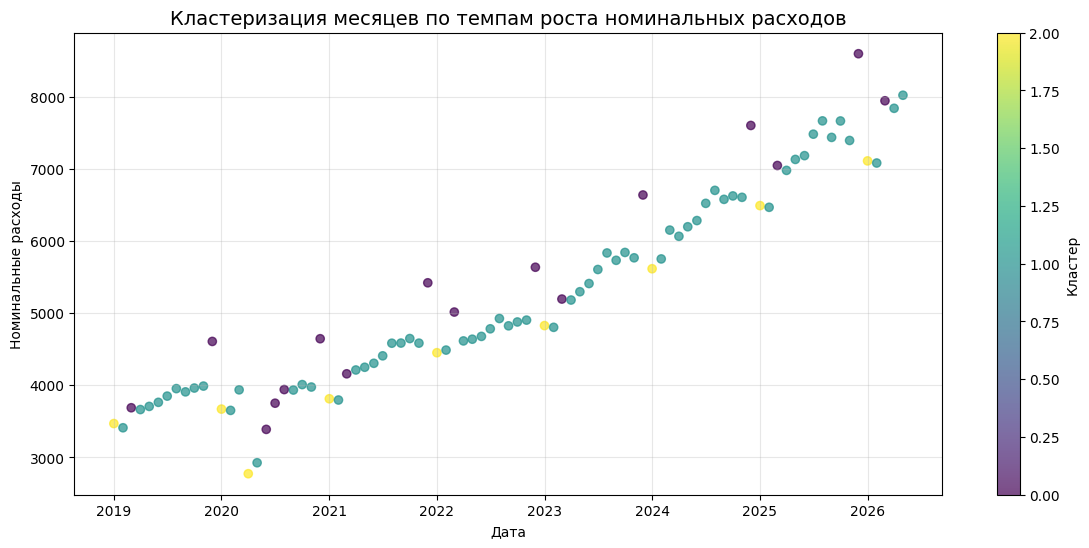


КЛАСТЕР 0:
  March 2019, December 2019, June 2020, July 2020, August 2020, December 2020, March 2021, December 2021, March 2022, December 2022, March 2023, December 2023, December 2024, March 2025, December 2025, March 2026

КЛАСТЕР 1:
  February 2019, April 2019, May 2019, June 2019, July 2019, August 2019, September 2019, October 2019, November 2019, February 2020, March 2020, May 2020, September 2020, October 2020, November 2020, February 2021, April 2021, May 2021, June 2021, July 2021, August 2021, September 2021, October 2021, November 2021, February 2022, April 2022, May 2022, June 2022, July 2022, August 2022, September 2022, October 2022, November 2022, February 2023, April 2023, May 2023, June 2023, July 2023, August 2023, September 2023, October 2023, November 2023, February 2024, March 2024, April 2024, May 2024, June 2024, July 2024, August 2024, September 2024, October 2024, November 2024, February 2025, April 2025, May 2025, June 2025, July 2025, August 2025, September 

In [ ]:
# График для номинальных расходов
plt.figure(figsize=(14, 6))

plt.scatter(
    cluster_df['date'],
    cluster_df['nominal_total'],
    c=cluster_df['cluster'],
    alpha=0.7
)

plt.title('Кластеризация месяцев по темпам роста номинальных расходов', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Номинальные расходы')
plt.colorbar(label='Кластер')
plt.grid(alpha=0.3)
plt.show()

# Вывод месяцев по кластерам
for cluster in sorted(cluster_df['cluster'].unique()):
    print(f'\nКЛАСТЕР {cluster}:')
    months = cluster_df[cluster_df['cluster'] == cluster]['date'].dt.strftime('%B %Y').tolist()
    print(f'  {", ".join(months)}')

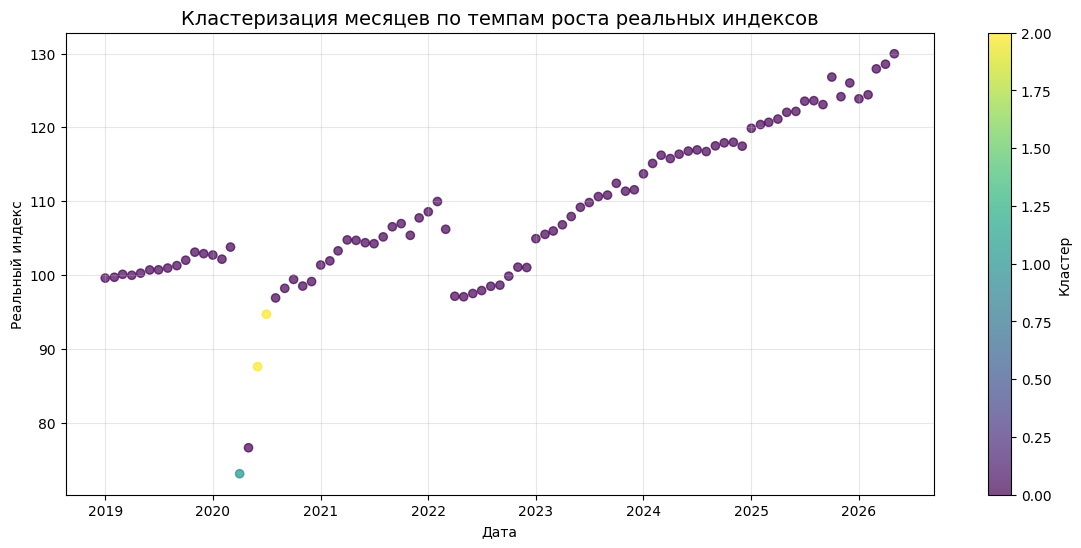


КЛАСТЕР 0: January 2019, February 2019, March 2019, April 2019, May 2019, June 2019, July 2019, August 2019, September 2019, October 2019, November 2019, December 2019, January 2020, February 2020, March 2020, May 2020, August 2020, September 2020, October 2020, November 2020, December 2020, January 2021, February 2021, March 2021, April 2021, May 2021, June 2021, July 2021, August 2021, September 2021, October 2021, November 2021, December 2021, January 2022, February 2022, March 2022, April 2022, May 2022, June 2022, July 2022, August 2022, September 2022, October 2022, November 2022, December 2022, January 2023, February 2023, March 2023, April 2023, May 2023, June 2023, July 2023, August 2023, September 2023, October 2023, November 2023, December 2023, January 2024, February 2024, March 2024, April 2024, May 2024, June 2024, July 2024, August 2024, September 2024, October 2024, November 2024, December 2024, January 2025, February 2025, March 2025, April 2025, May 2025, June 2025, 

In [ ]:
plt.figure(figsize=(14, 6))

scatter = plt.scatter(
    real_cluster_df['date'],
    real_cluster_df['real_total'],
    c=real_cluster_df['cluster'],
    alpha=0.7
)

plt.title('Кластеризация месяцев по темпам роста реальных индексов', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Реальный индекс')
plt.colorbar(scatter, label='Кластер')
plt.grid(alpha=0.3)
plt.show()

# Вывод месяцев по кластерам
for cluster in sorted(real_cluster_df['cluster'].unique()):
    months = real_cluster_df[real_cluster_df['cluster'] == cluster]['date'].dt.strftime('%B %Y').tolist()
    print(f'\nКЛАСТЕР {cluster}: {", ".join(months)}')

Полученные кластеры отражают различные режимы поведения потребительских расходов. Анализ состава кластеров позволяет выделить периоды стабильности, роста и кризисов.


**Кластер 0 («Стабильность»):** Самый большой кластер (64 месяца). Включает обычные месяцы, где рост расходов близок к среднему. Сюда попали почти все «нормальные» месяцы вне кризисов.

**Кластер 1 («Кризисные падения»):** 9 месяцев, включая январь 2019, 2020, 2021, 2022, 2023, 2024, 2025 и апрель 2020. Это месяцы с самым сильным падением номинальных расходов (в среднем -20%), в которые обычно происходит «провал» после праздничного роста или в разгар кризиса.

**Кластер 2 («Праздничный/активный рост»):** 16 месяцев (марты и декабри разных лет). Характеризуется сильным ростом всех категорий расходов (+10-14%). Это месяцы высокой покупательской активности (подготовка к праздникам, сезонные распродажи).

**Вывод:** Кластеризация наглядно показала три ключевых типа месяцев: стабильные, кризисные и «праздничные», что подтверждает предположения о поведении потребителей.

# **Гипотезы**

###**Проверка гипотезы о сезонности**

Одной из задач исследования является анализ сезонного поведения различных категорий потребительских расходов.

Предполагается, что расходы на общественное питание и продовольственные товары имеют схожую сезонную динамику, поскольку обе категории напрямую связаны с потреблением продуктов питания населением.

Для проверки данной гипотезы рассчитываются средние значения показателей для каждого месяца года, после чего определяется коэффициент корреляции между сезонными профилями категорий.

**Нулевая гипотеза (H₀):**

Сезонная структура расходов на общественное питание **не совпадает** с сезонной структурой расходов на продовольственные товары.

**Альтернативная гипотеза (H₁):**

Сезонная структура расходов на общественное питание **совпадает** с сезонной структурой расходов на продовольственные товары.

**Критерий принятия решения:**
Если коэффициент корреляции между сезонными профилями составляет не менее 0.7, гипотеза H₁ считается подтвержденной. В противном случае принимается H₀.

КОРРЕЛЯЦИЯ НОМИНАЛЬНЫХ РАСХОДОВ
0.4911

КОРРЕЛЯЦИЯ РЕАЛЬНЫХ РАСХОДОВ
0.8036


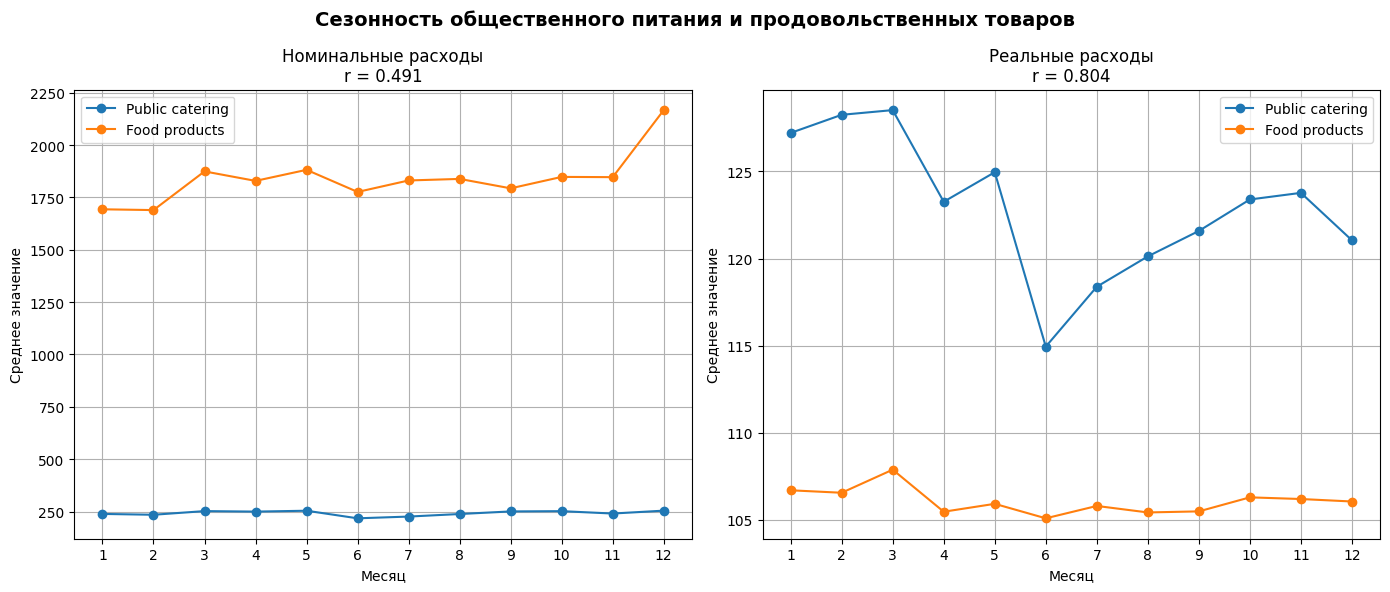

In [ ]:
# Создание признака номера месяца
df['month'] = df['date'].dt.month

# Анализ номинальных расходов

# Расчёт средних значений по месяцам
nominal_seasonality = (
    df.groupby('month')
    [
        [
            'nominal_public_catering',
            'nominal_food_products'
        ]
    ]
    .mean()
)

# Расчёт корреляционной матрицы
nominal_corr = (
    nominal_seasonality
    [
        [
            'nominal_public_catering',
            'nominal_food_products'
        ]
    ]
    .corr()
)

# Извлечение коэффициента корреляции
nominal_corr_value = nominal_corr.loc[
    'nominal_public_catering',
    'nominal_food_products'
]

print('КОРРЕЛЯЦИЯ НОМИНАЛЬНЫХ РАСХОДОВ')

print(
    round(
        nominal_corr_value,
        4
    )
)


# Анализ реальных расходов

# Расчёт средних значений по месяцам
real_seasonality = (
    df.groupby('month')
    [
        [
            'real_public_catering',
            'real_food_products'
        ]
    ]
    .mean()
)

# Расчёт корреляционной матрицы

real_corr = (
    real_seasonality
    [
        [
            'real_public_catering',
            'real_food_products'
        ]
    ]
    .corr()
)

# Извлечение коэффициента корреляции
real_corr_value = real_corr.loc[
    'real_public_catering',
    'real_food_products'
]

print('\nКОРРЕЛЯЦИЯ РЕАЛЬНЫХ РАСХОДОВ')

print(
    round(
        real_corr_value,
        4
    )
)


# Построение графиков
plt.figure(figsize=(14, 6))

plt.suptitle(
    'Сезонность общественного питания и продовольственных товаров',
    fontsize=14,
    fontweight='bold'
)


# График номинальных расходов
plt.subplot(1, 2, 1)

plt.plot(
    nominal_seasonality.index,
    nominal_seasonality[
        'nominal_public_catering'
    ],
    marker='o',
    label='Public catering'
)

plt.plot(
    nominal_seasonality.index,
    nominal_seasonality[
        'nominal_food_products'
    ],
    marker='o',
    label='Food products'
)

plt.title(
    f'Номинальные расходы\nr = {nominal_corr_value:.3f}'
)

plt.xlabel('Месяц')

plt.ylabel('Среднее значение')

plt.xticks(range(1, 13))

plt.legend()

plt.grid()

# График реальных расходов
plt.subplot(1, 2, 2)

plt.plot(
    real_seasonality.index,
    real_seasonality[
        'real_public_catering'
    ],
    marker='o',
    label='Public catering'
)

plt.plot(
    real_seasonality.index,
    real_seasonality[
        'real_food_products'
    ],
    marker='o',
    label='Food products'
)

plt.title(
    f'Реальные расходы\nr = {real_corr_value:.3f}'
)

plt.xlabel('Месяц')

plt.ylabel('Среднее значение')

plt.xticks(range(1, 13))

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

####**Вывод**

Коэффициент корреляции между сезонными профилями общественного питания и продовольственных товаров в номинальном выражении составил 0,491. Это значение ниже установленного порога (0,7), поэтому *гипотеза H₁ не подтверждается.*


Коэффициент корреляции между сезонными профилями в реальном выражении составил 0,804, что превышает порог в 0,7. *Гипотеза H₁ подтверждается.*

####Исходное предположение о схожести сезонности общепита и продуктов подтвердилось только для реальных показателей, так как именно они отражают фактическое физическое потребление, а не денежные траты, искажённые инфляцией и возможностью делать запасы.



---



###**Скорость восстановления после кризисов**

Кризисные события оказывают существенное влияние на потребительскую активность населения.

После каждого кризиса расходы постепенно возвращаются к нормальному уровню. Однако скорость восстановления номинальных расходов и индекса реальных расходов может различаться.

Для проверки гипотезы рассматриваются кризисные периоды марта 2020 года и марта 2022 года.

Для каждого кризиса определяется количество месяцев, необходимое:

- для восстановления номинальных расходов до докризисного уровня;
- для восстановления индекса реальных расходов до уровня 100.

**Нулевая гипотеза (H₀):**

Скорость восстановления номинальных и реальных расходов одинакова.

**Альтернативная гипотеза (H₁):**

Скорость восстановления номинальных и реальных расходов различается.

**Критерий принятия решения:** Сравниваются средние сроки восстановления. Если значения различаются, гипотеза H₀ отвергается.

,crisis_month,nominal_pre_crisis_level,real_pre_crisis_level,nominal_recovery_months,real_recovery_months
0,2019-01,4372.54,100.00,11.0,2
1,2020-01,4608.66,102.89,11.0,1
2,2020-04,3937.55,103.78,4.0,9
3,2021-01,4646.24,99.11,9.0,1
4,2022-01,5421.44,107.73,11.0,1
5,2026-01,8596.71,126.01,NaN,1


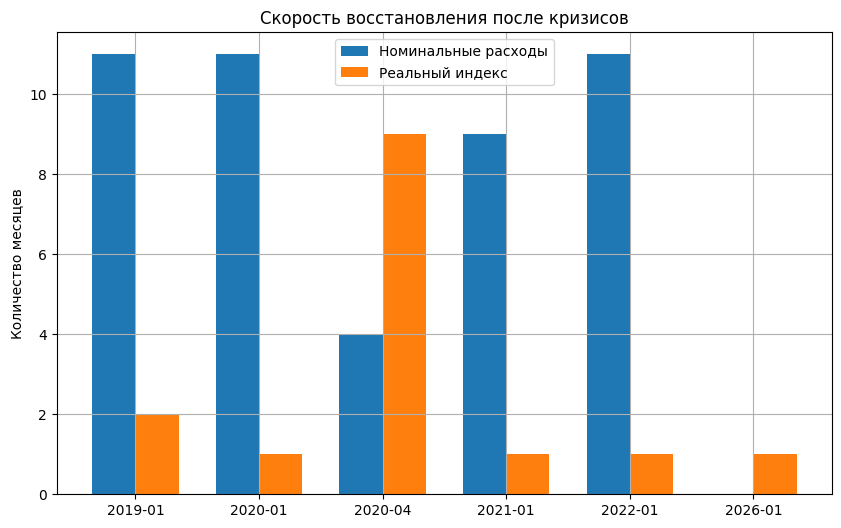

ВЫВОД:
Среднее восстановление номинальных расходов: 9.2 мес.
Среднее восстановление реального индекса: 2.5 мес.
Гипотеза не подтверждается: реальный индекс восстанавливается быстрее.


In [12]:
# Приведение даты к формату datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка данных по дате
df = df.sort_values('date').reset_index(drop=True)

# Создание признака периода в формате ГГГГ-ММ
df['period'] = df['date'].dt.strftime('%Y-%m')

# Список кризисных месяцев
crisis_months = crisis_df['date'].dt.strftime('%Y-%m').tolist()

# Создание списка для сохранения результатов
results = []

# Расчёт восстановления по каждому кризисному месяцу
for crisis_month in crisis_months:

    # Поиск строки с кризисным месяцем
    crisis_rows = df[df['period'] == crisis_month]

    # Проверка наличия кризисного месяца в данных
    if len(crisis_rows) == 0:
        print('Месяц не найден в данных:', crisis_month)
        continue

    # Получение индекса кризисного месяца
    crisis_index = crisis_rows.index[0]

    # Проверка наличия докризисного месяца
    if crisis_index == 0:
        print('Для месяца нет предыдущего значения:', crisis_month)
        continue

    # Определение докризисного уровня номинальных расходов
    nominal_before = df.loc[crisis_index - 1, 'nominal_total']

    # Определение докризисного уровня реального индекса
    real_before = df.loc[crisis_index - 1, 'real_total']

    # Создание переменных для срока восстановления
    nominal_recovery = None
    real_recovery = None

    # Поиск месяца восстановления после кризиса
    for i in range(crisis_index + 1, len(df)):

        # Проверка восстановления номинальных расходов
        if nominal_recovery is None:
            if df.loc[i, 'nominal_total'] >= nominal_before:
                nominal_recovery = i - crisis_index

        # Проверка восстановления реального индекса
        if real_recovery is None:
            if df.loc[i, 'real_total'] >= 100:
                real_recovery = i - crisis_index

        # Завершение поиска, если оба показателя восстановились
        if nominal_recovery is not None and real_recovery is not None:
            break

    # Сохранение результата по кризисному месяцу
    results.append([
        crisis_month,
        nominal_before,
        real_before,
        nominal_recovery,
        real_recovery
    ])

# Формирование таблицы результатов
recovery_df = pd.DataFrame(
    results,
    columns=[
        'crisis_month',
        'nominal_pre_crisis_level',
        'real_pre_crisis_level',
        'nominal_recovery_months',
        'real_recovery_months'
    ]
)

# Вывод таблицы восстановления
display(recovery_df)

# Построение графика
plt.figure(figsize=(10, 6))

x = range(len(recovery_df))
width = 0.35

# Столбцы для номинальных расходов
plt.bar(
    [i - width / 2 for i in x],
    recovery_df['nominal_recovery_months'],
    width=width,
    label='Номинальные расходы'
)

# Столбцы для реального индекса
plt.bar(
    [i + width / 2 for i in x],
    recovery_df['real_recovery_months'],
    width=width,
    label='Реальный индекс'
)

# Настройка подписей графика
plt.xticks(x, recovery_df['crisis_month'])
plt.ylabel('Количество месяцев')
plt.title('Скорость восстановления после кризисов')
plt.legend()
plt.grid()

plt.show()

# Формирование вывода
print('ВЫВОД:')

# Расчёт среднего срока восстановления
nominal_avg = recovery_df['nominal_recovery_months'].mean()
real_avg = recovery_df['real_recovery_months'].mean()

print(
    'Среднее восстановление номинальных расходов:',
    round(nominal_avg, 2),
    'мес.'
)

print(
    'Среднее восстановление реального индекса:',
    round(real_avg, 2),
    'мес.'
)

# Проверка гипотезы
if nominal_avg == real_avg:
    print(
        'Гипотеза подтверждается: скорость восстановления одинакова.'
    )

elif nominal_avg < real_avg:
    print(
        'Гипотеза не подтверждается: '
        'номинальные расходы восстанавливаются быстрее.'
    )

else:
    print(
        'Гипотеза не подтверждается: '
        'реальный индекс восстанавливается быстрее.'
    )

В рамках данного этапа была проверена гипотеза о равенстве скорости восстановления номинальных и реальных потребительских расходов после кризисных периодов. Полученные результаты показали, что средний срок восстановления номинальных расходов составил 9,2 месяца, тогда как средний срок восстановления реального индекса составил 2,5 месяца.

Таким образом, реальный индекс восстанавливался существенно быстрее номинальных расходов. Это свидетельствует о том, что после кризисов потребительская активность населения возвращалась к нормальному уровню раньше, чем восстанавливался общий денежный объём расходов. Следовательно, нулевая гипотеза о равенстве скорости восстановления отвергается. Полученные результаты подтверждают альтернативную гипотезу о том, что скорость восстановления номинальных и реальных расходов различается.

Также следует отметить, что для кризисного периода января 2026 года восстановление номинальных расходов не было зафиксировано до конца доступного периода наблюдений, что может быть связано с недостаточной длиной временного ряда после данного кризиса.

###**Анализ опережающей способности показателя gap**

> gap = темп роста номинальных расходов - темп роста реальных расходов

Экономически данный показатель отражает расхождение между денежным объёмом расходов населения и изменением их реательной покупательной способности.

Предполагается, что резкие изменения показателя gap могут возникать раньше существенных изменений индекса реальных расходов и поэтому способны выступать в роли опережающего индикатора.

Для проверки гипотезы сначала выявляются выбросы показателя gap и темпов роста реальных расходов.

Выбросами считаются наблюдения, выходящие за пределы двух стандартных отклонений от среднего значения.

После этого анализируется, возникают ли выбросы реальных расходов в течение трёх месяцев после появления выбросов gap.

**Нулевая гипотеза (H₀):**

Выбросы показателя gap не предшествуют выбросам индекса реальных расходов.

**Альтернативная гипотеза (H₁):**

Выбросы показателя gap предшествуют выбросам индекса реальных расходов и могут рассматриваться как ранний индикатор изменений потребительской активности.

**Критерий принятия решения:**
Если более половины выбросов gap сопровождаются последующим появлением выбросов индекса в течение трёх месяцев, гипотеза H₁ считается частично подтверждённой.

In [ ]:

gap_series = df.set_index('date')['gap'].dropna()
real_growth_series = df.set_index('date')['real_growth_pct'].dropna()

def find_outliers(series):
    mean = series.mean()
    std = series.std()
    upper = mean + 2 * std
    lower = mean - 2 * std
    outliers = series[(series > upper) | (series < lower)]
    return outliers, mean, std, upper, lower

# Поиск выбросов
gap_outliers, gap_mean, gap_std, gap_upper, gap_lower = find_outliers(gap_series)
real_outliers, real_mean, real_std, real_upper, real_lower = find_outliers(real_growth_series)

print(f'Среднее значение gap: {gap_mean:.2f}')
print(f'Стандартное отклонение: {gap_std:.2f}')
print(f'Верхняя граница: {gap_upper:.2f}')
print(f'Нижняя граница: {gap_lower:.2f}')
print(f'\nКоличество выбросов gap: {len(gap_outliers)}')
print(f'Количество выбросов реального индекса: {len(real_outliers)}')

# Поиск случаев, когда выброс gap предшествовал выбросу индекса (в течение 3 месяцев)
lead_results = []

for gap_date in gap_outliers.index:
    # Ищем выбросы индекса в следующие 3 месяца
    # Используем pd.DateOffset, как у вас в коде выше
    future_mask = (real_outliers.index > gap_date) & (real_outliers.index <= gap_date + pd.DateOffset(months=3))
    future_outliers = real_outliers[future_mask]

    for real_date in future_outliers.index:
        # Считаем лаг в месяцах правильно
        lag = (real_date.year - gap_date.year) * 12 + (real_date.month - gap_date.month)
        lead_results.append({
            'gap_outlier_date': gap_date,
            'real_outlier_date': real_date,
            'lag_months': lag
        })

lead_df = pd.DataFrame(lead_results)

print(f'\nКоличество случаев, когда выброс gap предшествовал выбросу индекса: {len(lead_df)}')
if len(lead_df) > 0:
    for i, row in lead_df.iterrows():
        print(f"{row['gap_outlier_date'].strftime('%B %Y')}  -> {row['real_outlier_date'].strftime('%B %Y')}")

# Процент подтверждения гипотезы
if len(gap_outliers) > 0:
    confirmation_rate = len(lead_df) / len(gap_outliers) * 100
    print(f'\nДоля подтверждений гипотезы: {confirmation_rate:.1f}%')

Среднее значение gap: 0.68
Стандартное отклонение: 7.67
Верхняя граница: 16.03
Нижняя граница: -14.67

Количество выбросов gap: 9
Количество выбросов реального индекса: 3

Количество случаев, когда выброс gap предшествовал выбросу индекса: 2
January 2020  -> April 2020
January 2022  -> April 2022

Доля подтверждений гипотезы: 22.2%


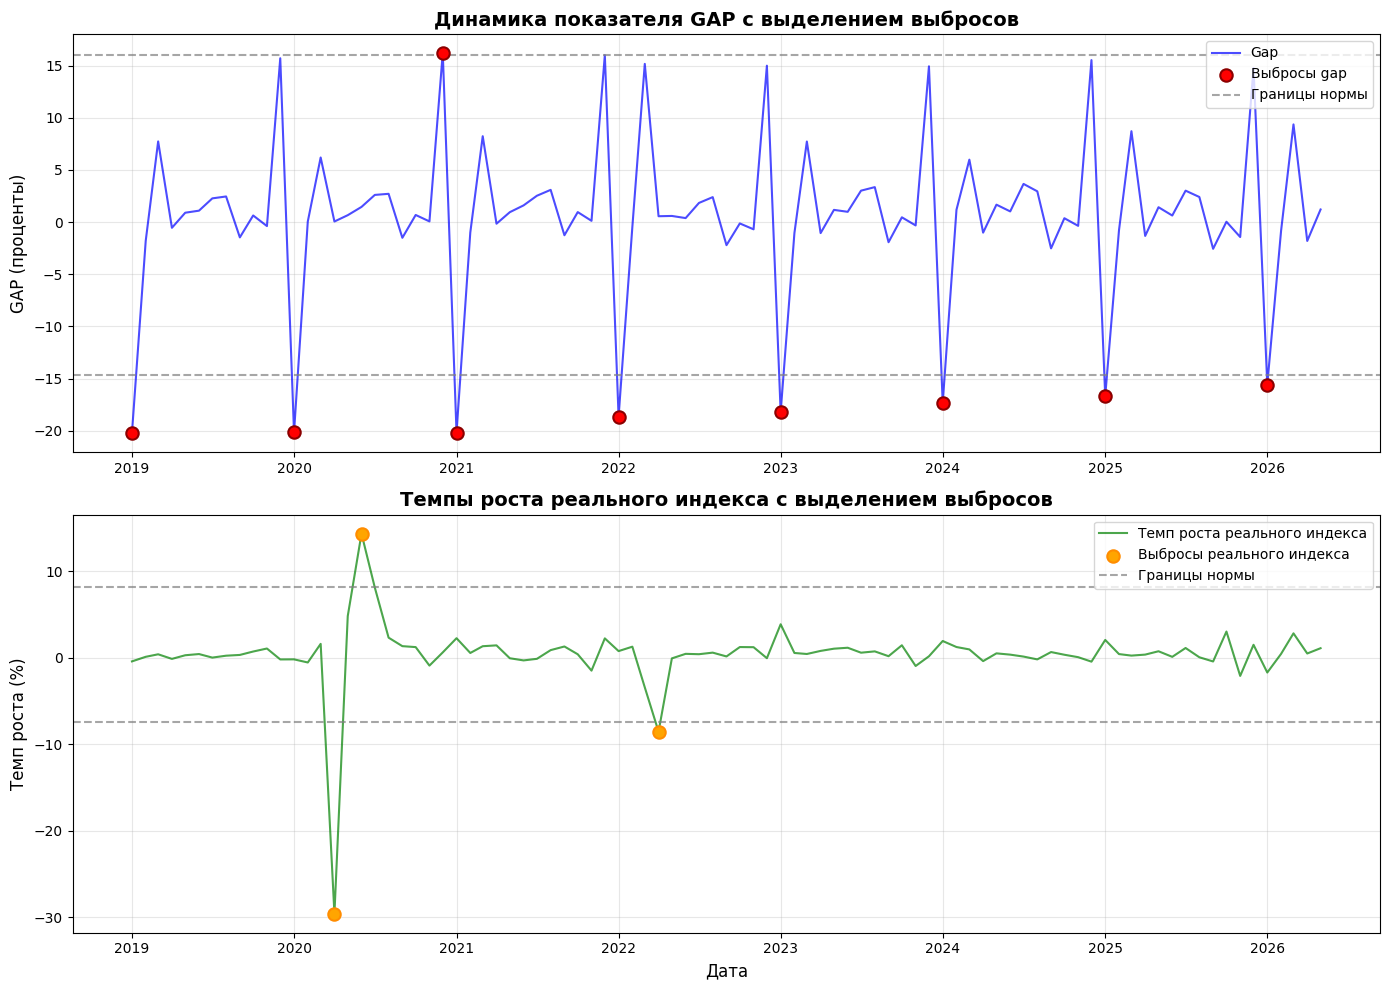

In [ ]:
# Создание двух графиков
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# динамика gap
ax1 = axes[0]

ax1.plot(gap_series.index, gap_series.values, 'b-', linewidth=1.5, alpha=0.7, label='Gap')

ax1.scatter(gap_outliers.index, gap_outliers.values, color='red', s=80, zorder=5,
            label='Выбросы gap', edgecolors='darkred', linewidth=1.5)

ax1.axhline(y=gap_upper, color='gray', linestyle='--', alpha=0.7, label='Границы нормы')
ax1.axhline(y=gap_lower, color='gray', linestyle='--', alpha=0.7)

ax1.set_title('Динамика показателя GAP с выделением выбросов', fontsize=14, fontweight='bold')
ax1.set_ylabel('GAP (проценты)', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# динамика индексов
ax2 = axes[1]

ax2.plot(real_growth_series.index, real_growth_series.values, 'g-', linewidth=1.5, alpha=0.7,
         label='Темп роста реального индекса')

ax2.scatter(real_outliers.index, real_outliers.values, color='orange', s=80, zorder=5,
            label='Выбросы реального индекса', edgecolors='darkorange', linewidth=1.5)

ax2.axhline(y=real_upper, color='gray', linestyle='--', alpha=0.7, label='Границы нормы')
ax2.axhline(y=real_lower, color='gray', linestyle='--', alpha=0.7)

ax2.set_title('Темпы роста реального индекса с выделением выбросов', fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата', fontsize=12)
ax2.set_ylabel('Темп роста (%)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Гипотеза не подтверждается в статистическом смысле, но выявленные случаи опережения могут рекомендовать gap как вспомогательный качественный индикатор.

**Несмотря на низкую долю, два зарегистрированных опережения происходят за 3 месяца до выбросов реального индекса и соответствуют периодам реальных экономических кризисов (локдаун и начало СВО).**

# **Итоговые выводы по проекту**

В ходе исследования был проведён сравнительный анализ номинальных и реальных потребительских расходов населения России за 2018–2026 годы по данным СберИндекса.

1. На первом этапе были собраны данные посредством API СберИндекса, объединены в единую таблицу и подготовлены для дальнейшего анализа. Была проведена проверка качества данных, выполнено преобразование типов данных и сформированы дополнительные признаки, необходимые для проведения статистического исследования.

2. В ходе анализа были выявлены кризисные месяцы на основе статистического подхода, основанного на исследовании темпов роста потребительских расходов. Для определения кризисных периодов использовались методы выявления аномальных наблюдений временного ряда. **Этим методом выявлено 6 кризисных месяцев. **

3. Корреляционный анализ показал наличие статистической связи между номинальными потребительскими расходами и индексом реальных расходов. Коэффициент корреляции Пирсона между номинальными расходами и реальным индексом составил 0.916. **Связь очень сильная и прямая**, что подтверждает согласованность денежной и физической потребительской активности.

4. Сравнение структуры потребительских расходов в 2018 и 2026 годах позволило выявить изменения в распределении расходов между основными категориями потребления. Наиболее сильно выросли номинальные расходы на общественное питание (+189%). Реальный индекс общественного питания также показал максимальный рост (+81%). **Это говорит о значительном изменении потребительских привычек в сторону сервисного потребления.**

5. **Исследование волатильности** показало, что различные категории расходов обладают разной степенью устойчивости к изменениям экономической ситуации. Номинально наиболее волатильны непродовольственные товары и продукты. Реально наиболее волатильно общественное питание, наименее - продукты. Продукты можно покупать впрок, а общепит не допускает запасов, соответственно случаются сильные колебания в кризис и праздники.

6. Дополнительный анализ кризисных периодов позволил определить категории расходов, наиболее чувствительные к экономическим шокам. **В кризисные месяцы максимальное падение было у общественного питания (до -50% номинально, до -51% реально).**

7. С помощью алгоритма кластеризации K-Means месяцы были распределены на группы со схожими характеристиками темпов роста расходов. Выделено три устойчивых кластера:
Стабильность (64 месяца) - нормальные месяцы.
Кризисные падения (9 месяцев) - сильное снижение после праздников или в кризис.
Активный рост в праздники или предсезонья (16 месяцев).
**Результаты подтверждают гипотезу о типовых режимах потребительского поведения.**

---


В рамках исследования были проверены несколько гипотез.

1. Сезонность трат на общественное питание и продукты совпадает только в реальном выражении, так как номинальные траты искажены инфляцией и возможностью создания запасов.

2. Реальные расходы восстанавливаются после кризисов быстрее номинальных, что свидетельствует о более быстром восстановлении потребительской активности по сравнению с денежным объёмом расходов.

3. Выявленные случаи опережения экономически значимы и позволяют рекомендовать gap как вспомогательный качественный индикатор.

